# Model Experiment — ARIMA

## Section 1 — Install & Imports

In [1]:
!pip install pmdarima --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima

from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.8 MB/s eta 0:00:00
Mounted at /content/drive


## Section 2 — Load Cleaned Data

In [2]:
path = '/content/drive/MyDrive/ML-final/data/processed/'
df = pd.read_csv(path + 'walmart_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)  # SARIMAX exog can't take NaN either

print(df.shape)
df.head()


(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,2,2010-02-05,50605.27,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
2,1,3,2010-02-05,13740.12,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
3,1,4,2010-02-05,39954.04,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
4,1,5,2010-02-05,32229.38,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106


## Section 3 — Wandb Login

In [3]:
wandb.login()


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gormo22 (gormo22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Section 4 — Series Selection (`ARIMA_Series_Selection`)

Fitting a genuinely separate SARIMAX per (Store, Dept) series (~3,000 combinations) is
out of scope given the assignment's explicit guidance to limit time spent on classical
models. Instead we fit/evaluate ARIMA properly on a **stratified sample**: a few
high-volume series, a few mid-volume, a few low-volume/sparse ones. This is a
deliberate scoping decision, logged here, and discussed in the README as a limitation
of per-series classical modeling versus pooled tree/DL models.

Note: SARIMA (the seasonal counterpart) is treated as its own separate architecture
in `model_experiment_SARIMA.ipynb`, matching the assignment's file-per-architecture
convention. This notebook covers plain ARIMA only.

In [4]:
run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_Series_Selection", job_type="scoping")

series_totals = df.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().sort_values(ascending=False)
series_lengths = df.groupby(['Store', 'Dept']).size()

# keep only reasonably complete series (>=100 weeks) so ARIMA has enough data to fit
valid_series = series_lengths[series_lengths >= 100].index
series_totals = series_totals[series_totals.index.isin(valid_series)]

top_series = series_totals.head(5).index.tolist()
mid_start = len(series_totals) // 2
mid_series = series_totals.iloc[mid_start:mid_start + 3].index.tolist()
low_series = series_totals.tail(2).index.tolist()

selected_series = top_series + mid_series + low_series
print("Selected (Store, Dept) series for ARIMA:")
for s in selected_series:
    print(s, "-> total sales:", round(series_totals[s], 2))

wandb.config.update({
    "sampling_strategy": "stratified_top5_mid3_low2_by_total_revenue",
    "n_series_selected": len(selected_series),
    "selected_series": [str(s) for s in selected_series],
})
wandb.finish()


Selected (Store, Dept) series for ARIMA:
(14, 92) -> total sales: 26101497.71
(2, 92) -> total sales: 23572153.03
(20, 92) -> total sales: 23542625.04
(13, 92) -> total sales: 23170876.2
(4, 92) -> total sales: 22789210.43
(28, 24) -> total sales: 1191029.24
(45, 22) -> total sales: 1190340.69
(3, 8) -> total sales: 1188366.35
(17, 45) -> total sales: 2235.88
(36, 25) -> total sales: 2210.11


## Section 5 — Series Preparation (reindex + gap filling)

In [5]:
def prep_series(data, store, dept):
    s = data[(data['Store'] == store) & (data['Dept'] == dept)].sort_values('Date')
    s = s.set_index('Date')
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq='W-FRI')  # Walmart weeks
    s = s.reindex(full_idx)
    s.index.name = 'Date'

    # Weekly_Sales: interpolate small gaps -- documented choice, not silent
    s['Weekly_Sales'] = s['Weekly_Sales'].interpolate(limit_direction='both')
    # exogenous columns: forward/back fill (slow-moving or calendar-derivable)
    for col in ['IsHoliday', 'CPI', 'Unemployment', 'Fuel_Price'] + markdown_cols:
        if col in s.columns:
            s[col] = s[col].ffill().bfill()

    s['Store'] = store
    s['Dept'] = dept
    return s

prepared_series = {s: prep_series(df, s[0], s[1]) for s in selected_series}
for s, data in prepared_series.items():
    n_raw = df[(df['Store'] == s[0]) & (df['Dept'] == s[1])].shape[0]
    print(f"Store {s[0]} Dept {s[1]}: {n_raw} raw rows -> {len(data)} rows after reindex")


Store 14 Dept 92: 143 raw rows -> 143 rows after reindex
Store 2 Dept 92: 143 raw rows -> 143 rows after reindex
Store 20 Dept 92: 143 raw rows -> 143 rows after reindex
Store 13 Dept 92: 143 raw rows -> 143 rows after reindex
Store 4 Dept 92: 143 raw rows -> 143 rows after reindex
Store 28 Dept 24: 143 raw rows -> 143 rows after reindex
Store 45 Dept 22: 143 raw rows -> 143 rows after reindex
Store 3 Dept 8: 143 raw rows -> 143 rows after reindex
Store 17 Dept 45: 105 raw rows -> 142 rows after reindex
Store 36 Dept 25: 112 raw rows -> 140 rows after reindex


## Section 6 — Stationarity Testing (`ARIMA_Stationarity_Check`)

In [6]:
run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_Stationarity_Check", job_type="diagnostics")

def check_stationarity(series):
    adf_p = adfuller(series.dropna())[1]                       # H0: non-stationary
    kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[1]  # H0: stationary
    return adf_p, kpss_p

stationarity_results = []
for s, data in prepared_series.items():
    series = data['Weekly_Sales']
    adf_p, kpss_p = check_stationarity(series)

    d = 0
    adf_p_d1, kpss_p_d1 = None, None
    if adf_p > 0.05:
        d = 1
        diffed = series.diff().dropna()
        adf_p_d1, kpss_p_d1 = check_stationarity(diffed)

    stationarity_results.append({
        "store": s[0], "dept": s[1], "adf_p": adf_p, "kpss_p": kpss_p,
        "chosen_d": d, "adf_p_after_d1": adf_p_d1, "kpss_p_after_d1": kpss_p_d1
    })
    print(f"Store {s[0]} Dept {s[1]}: ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f} -> d={d}")

stationarity_df = pd.DataFrame(stationarity_results)
wandb.log({"stationarity_results": wandb.Table(dataframe=stationarity_df)})
wandb.finish()


/tmp/ipykernel_1425/3490706289.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[1]  # H0: stationary
/tmp/ipykernel_1425/3490706289.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[1]  # H0: stationary
/tmp/ipykernel_1425/3490706289.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[1]  # H0: stationary
/tmp/ipykernel_1425/3490706289.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-

Store 14 Dept 92: ADF p=0.6770, KPSS p=0.0118 -> d=1
Store 2 Dept 92: ADF p=0.0516, KPSS p=0.0874 -> d=1
Store 20 Dept 92: ADF p=0.5214, KPSS p=0.0100 -> d=1
Store 13 Dept 92: ADF p=0.6332, KPSS p=0.0100 -> d=1
Store 4 Dept 92: ADF p=0.4991, KPSS p=0.0100 -> d=1
Store 28 Dept 24: ADF p=0.0000, KPSS p=0.1000 -> d=0
Store 45 Dept 22: ADF p=0.1177, KPSS p=0.1000 -> d=1
Store 3 Dept 8: ADF p=0.0570, KPSS p=0.0379 -> d=1
Store 17 Dept 45: ADF p=0.0385, KPSS p=0.1000 -> d=0
Store 36 Dept 25: ADF p=0.0001, KPSS p=0.0100 -> d=0


## Section 7 — Exogenous Feature Engineering (`ARIMA_Exogenous_Features`)

In [7]:
run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_Exogenous_Features", job_type="feature-engineering")

super_bowl    = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
labor_day     = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
thanksgiving  = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
christmas     = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

def fourier_terms(index, period=52.18, order=2):
    t = np.arange(len(index))
    terms = {}
    for k in range(1, order + 1):
        terms[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        terms[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(terms, index=index)

def build_exog(data):
    idx = data.index
    exog = fourier_terms(idx, order=2)
    exog['IsHoliday']        = data['IsHoliday'].astype(int).values
    exog['Is_SuperBowl']     = idx.isin(super_bowl).astype(int)
    exog['Is_LaborDay']      = idx.isin(labor_day).astype(int)
    exog['Is_Thanksgiving']  = idx.isin(thanksgiving).astype(int)
    exog['Is_Christmas']     = idx.isin(christmas).astype(int)
    exog['CPI']              = data['CPI'].values
    exog['Unemployment']     = data['Unemployment'].values
    exog['Fuel_Price']       = data['Fuel_Price'].values
    exog['Total_Markdown']   = data[markdown_cols].sum(axis=1).values
    exog['Has_Markdown']     = (exog['Total_Markdown'] > 0).astype(int)
    return exog

def standardize_exog_fold(train_exog, val_exog, cols=('CPI', 'Unemployment', 'Fuel_Price', 'Total_Markdown')):
    """Leakage-safe standardization: fit mu/sigma on the TRAIN portion only, apply to both.
    Same pattern as XGBoost's refit_fold_features() -- one shared routine, called fresh for
    every split, instead of standardizing over train+val combined before any split exists."""
    train_exog = train_exog.copy()
    val_exog = val_exog.copy()
    for col in cols:
        mu, sigma = train_exog[col].mean(), train_exog[col].std()
        sigma = sigma if sigma > 0 else 1
        train_exog[col] = (train_exog[col] - mu) / sigma
        val_exog[col] = (val_exog[col] - mu) / sigma
    return train_exog, val_exog

exog_by_series = {s: build_exog(data) for s, data in prepared_series.items()}
print("Exogenous feature matrix columns:", list(exog_by_series[selected_series[0]].columns))
print(exog_by_series[selected_series[0]].head())

wandb.config.update({
    "exog_features": list(exog_by_series[selected_series[0]].columns),
    "excluded_features_reason": "Sales_Lag*, RollMean/RollStd, Dept_Avg_Sales, Store_Avg_Sales, "
                                 "Partner_Dept omitted -- redundant with ARIMA's own AR/MA structure, "
                                 "risk of near-collinearity",
    "fourier_order": 2,
    "fourier_period_weeks": 52.18,
})
wandb.finish()


Exogenous feature matrix columns: ['sin_1', 'cos_1', 'sin_2', 'cos_2', 'IsHoliday', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas', 'CPI', 'Unemployment', 'Fuel_Price', 'Total_Markdown', 'Has_Markdown']
               sin_1     cos_1     sin_2     cos_2  IsHoliday  Is_SuperBowl  \
Date                                                                          
2010-02-05  0.000000  1.000000  0.000000  1.000000          0             0   
2010-02-12  0.120123  0.992759  0.238506  0.971141          1             1   
2010-02-19  0.238506  0.971141  0.463246  0.886230          0             0   
2010-02-26  0.353435  0.935459  0.661249  0.750167          0             0   
2010-03-05  0.463246  0.886230  0.821085  0.570806          0             0   

            Is_LaborDay  Is_Thanksgiving  Is_Christmas         CPI  \
Date                                                                 
2010-02-05            0                0             0  181.871190   
2010-02-12     

## Section 8 — Why Fourier Terms Instead of a Seasonal Component (`ARIMA_vs_Seasonal_Justification`)

A quick, one-series check to justify using plain ARIMA + Fourier exogenous terms here,
rather than a full seasonal component. A full seasonal search (m=52) is expensive and
is exactly what the separate `model_experiment_SARIMA.ipynb` notebook covers properly,
across all sampled series -- this cell is only a lightweight sanity check that the
Fourier approach is reasonable on its own, not a full model comparison.

In [8]:
import time

run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_vs_Seasonal_Justification", job_type="comparison")

check_key = selected_series[0]
data = prepared_series[check_key]
exog = exog_by_series[check_key]
series = data['Weekly_Sales']

cutoff_idx = int(len(series) * 0.9)
train_s, val_s = series.iloc[:cutoff_idx], series.iloc[cutoff_idx:]
train_exog, val_exog = exog.iloc[:cutoff_idx], exog.iloc[cutoff_idx:]

def wmae_from_holiday(y_true, y_pred, is_holiday):
    w = np.where(is_holiday == 1, 5, 1)
    return np.sum(w * np.abs(y_true - y_pred)) / np.sum(w)

t0 = time.time()
model_check = auto_arima(train_s, exogenous=train_exog, seasonal=False,
                          start_p=0, max_p=5, start_q=0, max_q=5, d=None,
                          stepwise=True, information_criterion='aic', suppress_warnings=True)
fit_time = time.time() - t0
preds_check = model_check.predict(n_periods=len(val_s), exogenous=val_exog)
wmae_check = wmae_from_holiday(val_s.values, preds_check, val_exog['IsHoliday'].values)

print(f"ARIMA + Fourier exog on {check_key}: order={model_check.order}, "
      f"fit_time={fit_time:.1f}s, val_wmae={wmae_check:.2f}")

wandb.log({"check_series_order": str(model_check.order), "check_series_fit_time_sec": fit_time,
           "check_series_val_wmae": wmae_check})
wandb.finish()


ARIMA + Fourier exog on (14, 92): order=(1, 0, 2), fit_time=1.9s, val_wmae=17286.81


check_series_fit_time_sec,▁
check_series_val_wmae,▁
check_series_fit_time_sec,1.89421
check_series_order,"(1, 0, 2)"
check_series_val_wmae,17286.80617


## Section 9 — Train/Validation Split (`ARIMA_Train_Val_Split`)

In [9]:
run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_Train_Val_Split", job_type="split")

cutoff_date = df['Date'].quantile(0.9, interpolation='nearest')  # same cutoff as XGBoost track
print("Cutoff date (matches XGBoost track):", cutoff_date)

train_val_split = {}
for s in selected_series:
    data = prepared_series[s]
    exog = exog_by_series[s]
    train_mask = data.index <= cutoff_date
    val_mask = data.index > cutoff_date
    train_exog, val_exog = standardize_exog_fold(exog[train_mask], exog[val_mask])
    train_val_split[s] = {
        "train_series": data['Weekly_Sales'][train_mask],
        "val_series":   data['Weekly_Sales'][val_mask],
        "train_exog":   train_exog,
        "val_exog":     val_exog,
    }
    print(f"Store {s[0]} Dept {s[1]}: train={train_mask.sum()}, val={val_mask.sum()}")

wandb.config.update({"cutoff_date": str(cutoff_date), "split_strategy": "same_cutoff_as_xgboost_time_based"})
wandb.finish()


Cutoff date (matches XGBoost track): 2012-07-20 00:00:00
Store 14 Dept 92: train=129, val=14
Store 2 Dept 92: train=129, val=14
Store 20 Dept 92: train=129, val=14
Store 13 Dept 92: train=129, val=14
Store 4 Dept 92: train=129, val=14
Store 28 Dept 24: train=129, val=14
Store 45 Dept 22: train=129, val=14
Store 3 Dept 8: train=129, val=14
Store 17 Dept 45: train=128, val=14
Store 36 Dept 25: train=126, val=14


## Section 10 — Order Selection + Training (`ARIMA_Training`)

In [10]:
run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_Training", job_type="training")

def weighted_mae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

trained_models = {}
training_results = []

for s in selected_series:
    split = train_val_split[s]
    train_s, val_s = split["train_series"], split["val_series"]
    train_exog, val_exog = split["train_exog"], split["val_exog"]

    if len(val_s) == 0 or len(train_s) < 52:
        print(f"Skipping Store {s[0]} Dept {s[1]}: insufficient data for train/val split")
        continue

    model = auto_arima(train_s, exogenous=train_exog, seasonal=False,
                        start_p=0, max_p=5, start_q=0, max_q=5, d=None,
                        stepwise=True, information_criterion='aic', suppress_warnings=True)
    preds = model.predict(n_periods=len(val_s), exogenous=val_exog)

    weights = np.where(val_exog['IsHoliday'].values == 1, 5, 1)
    wmae = weighted_mae(val_s.values, preds, weights)

    # seasonal-naive baseline: same week last year, falling back to last observed value
    naive_preds = train_s.reindex(val_s.index - pd.Timedelta(weeks=52))
    naive_preds.index = val_s.index
    naive_preds = naive_preds.fillna(train_s.iloc[-1])
    naive_wmae = weighted_mae(val_s.values, naive_preds.values, weights)

    trained_models[s] = model
    training_results.append({
        "store": s[0], "dept": s[1], "order": str(model.order),
        "aic": model.aic(), "val_wmae": wmae, "naive_wmae": naive_wmae,
        "beats_naive": bool(wmae < naive_wmae)
    })
    print(f"Store {s[0]} Dept {s[1]}: order={model.order}, val_wmae={wmae:.2f}, "
          f"naive_wmae={naive_wmae:.2f}, beats_naive={wmae < naive_wmae}")

training_results_df = pd.DataFrame(training_results)
wandb.log({"training_results": wandb.Table(dataframe=training_results_df)})
wandb.finish()
print(training_results_df)


Store 14 Dept 92: order=(1, 0, 2), val_wmae=19053.05, naive_wmae=30758.60, beats_naive=True
Store 2 Dept 92: order=(4, 0, 0), val_wmae=10816.46, naive_wmae=15884.55, beats_naive=True
Store 20 Dept 92: order=(0, 1, 5), val_wmae=10114.84, naive_wmae=7284.84, beats_naive=False
Store 13 Dept 92: order=(2, 1, 3), val_wmae=7474.94, naive_wmae=14293.30, beats_naive=True
Store 4 Dept 92: order=(2, 1, 3), val_wmae=8064.92, naive_wmae=9916.75, beats_naive=True
Store 28 Dept 24: order=(0, 0, 2), val_wmae=2704.53, naive_wmae=1792.44, beats_naive=False
Store 45 Dept 22: order=(3, 0, 3), val_wmae=678.25, naive_wmae=697.71, beats_naive=True
Store 3 Dept 8: order=(0, 1, 1), val_wmae=586.89, naive_wmae=810.67, beats_naive=True
Store 17 Dept 45: order=(5, 0, 0), val_wmae=12.50, naive_wmae=11.31, beats_naive=False
Store 36 Dept 25: order=(0, 1, 0), val_wmae=8.33, naive_wmae=4.98, beats_naive=False


   store  dept      order          aic      val_wmae    naive_wmae  \
0     14    92  (1, 0, 2)  2962.048463  19053.049001  30758.602222   
1      2    92  (4, 0, 0)  2872.326991  10816.462101  15884.547778   
2     20    92  (0, 1, 5)  2880.591944  10114.839495   7284.837778   
3     13    92  (2, 1, 3)  2831.017138   7474.937747  14293.302778   
4      4    92  (2, 1, 3)  2842.930690   8064.916611   9916.752778   
5     28    24  (0, 0, 2)  2434.403360   2704.530776   1792.443889   
6     45    22  (3, 0, 3)  2375.153503    678.247260    697.706111   
7      3     8  (0, 1, 1)  2004.448036    586.893189    810.667778   
8     17    45  (5, 0, 0)  1090.449322     12.500885     11.312381   
9     36    25  (0, 1, 0)  1028.835500      8.334524      4.983571   

   beats_naive  
0         True  
1         True  
2        False  
3         True  
4         True  
5        False  
6         True  
7         True  
8        False  
9        False  


## Section 11 — Residual Diagnostics (`ARIMA_Diagnostics`)

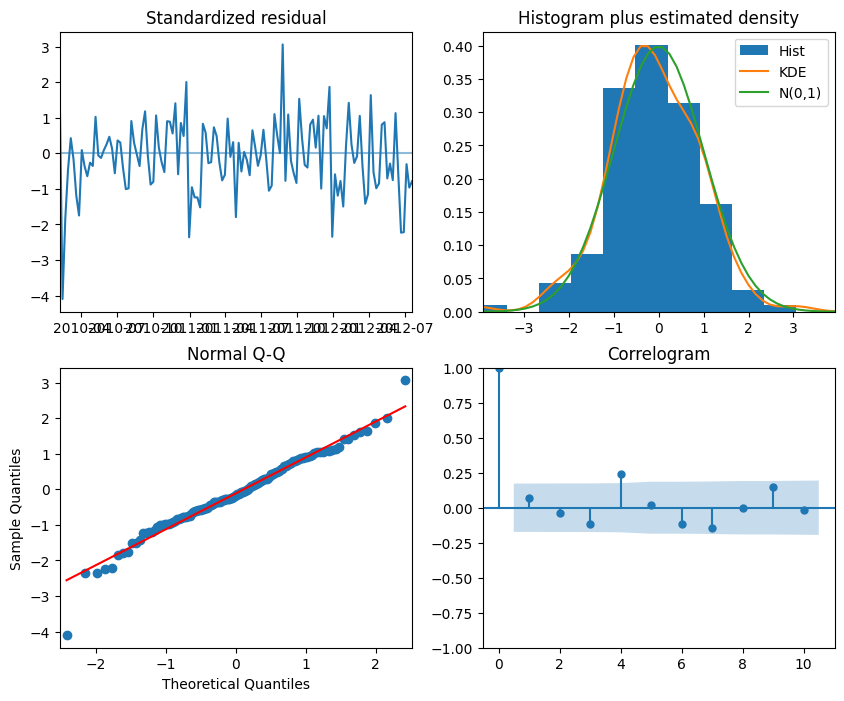

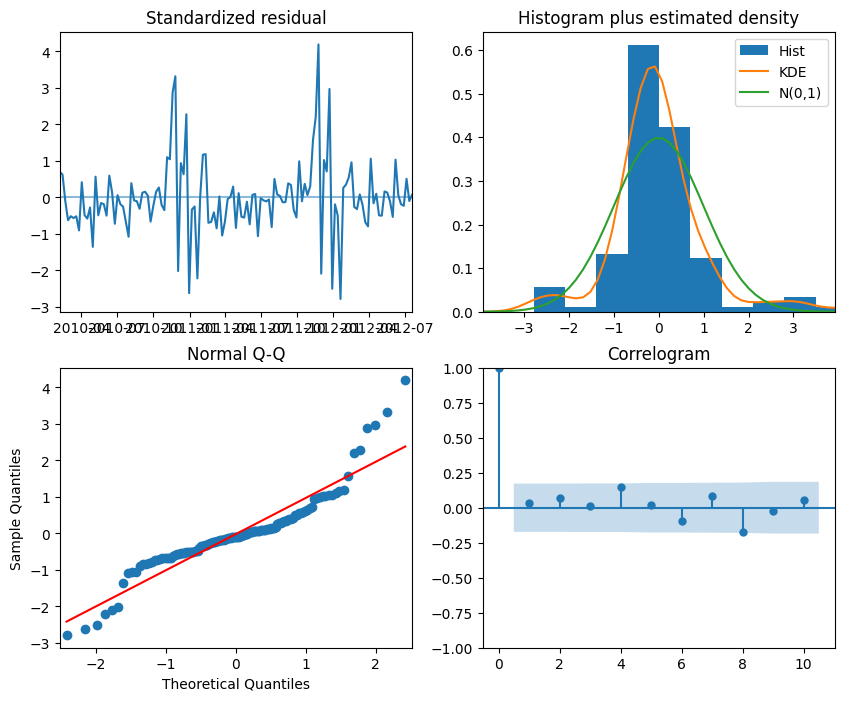

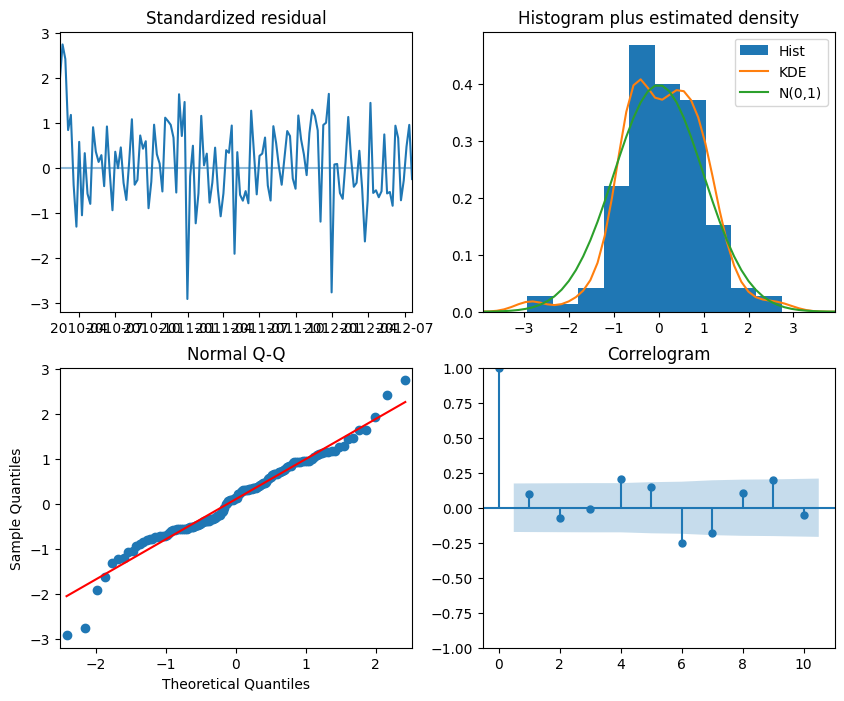

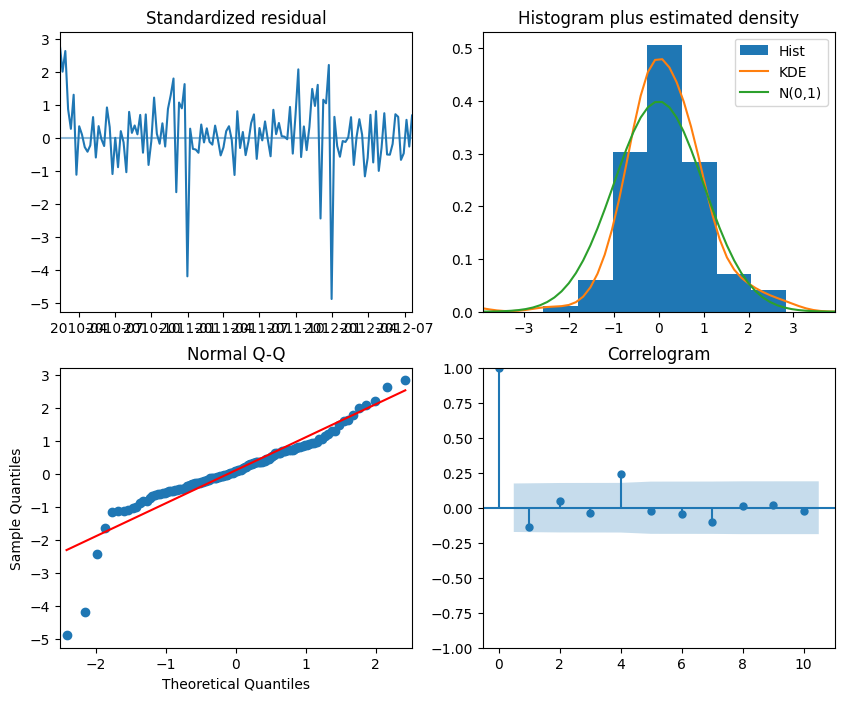

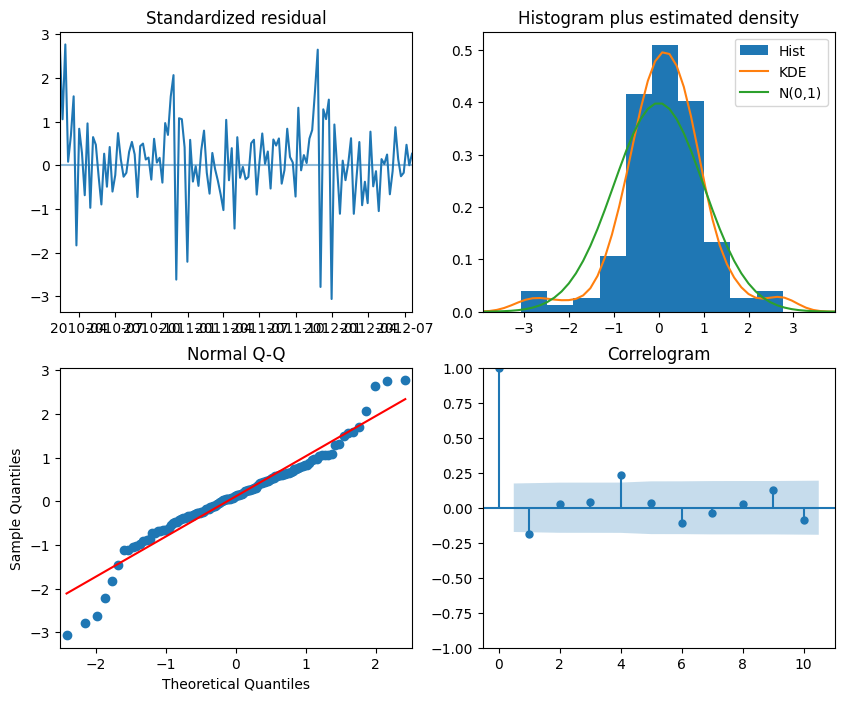

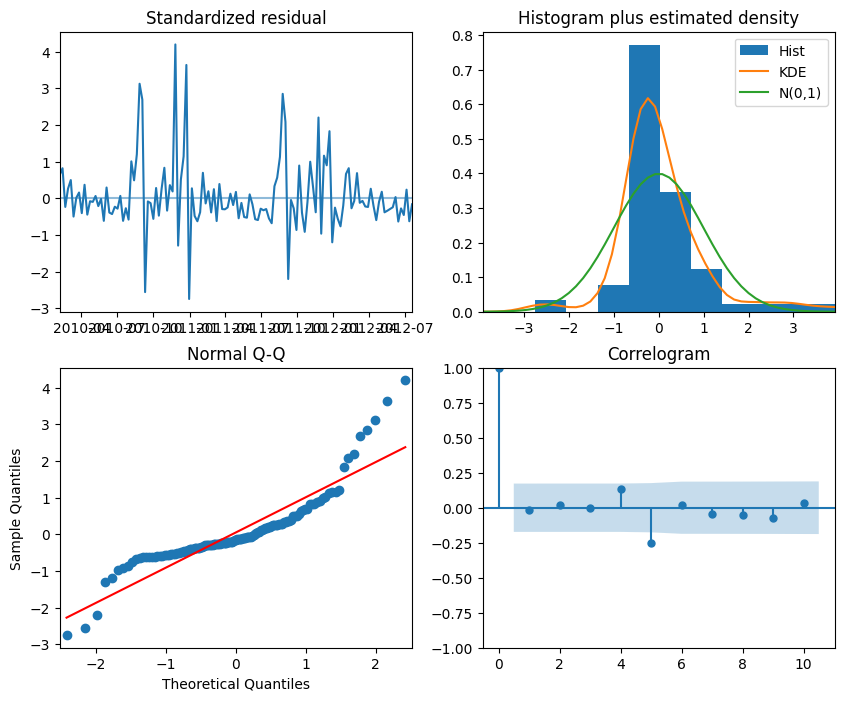

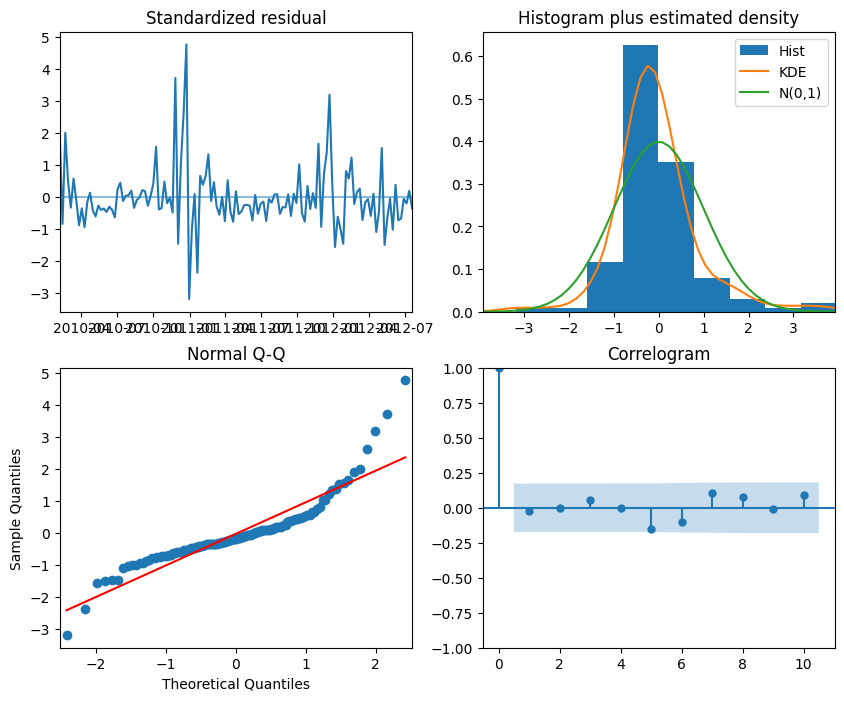

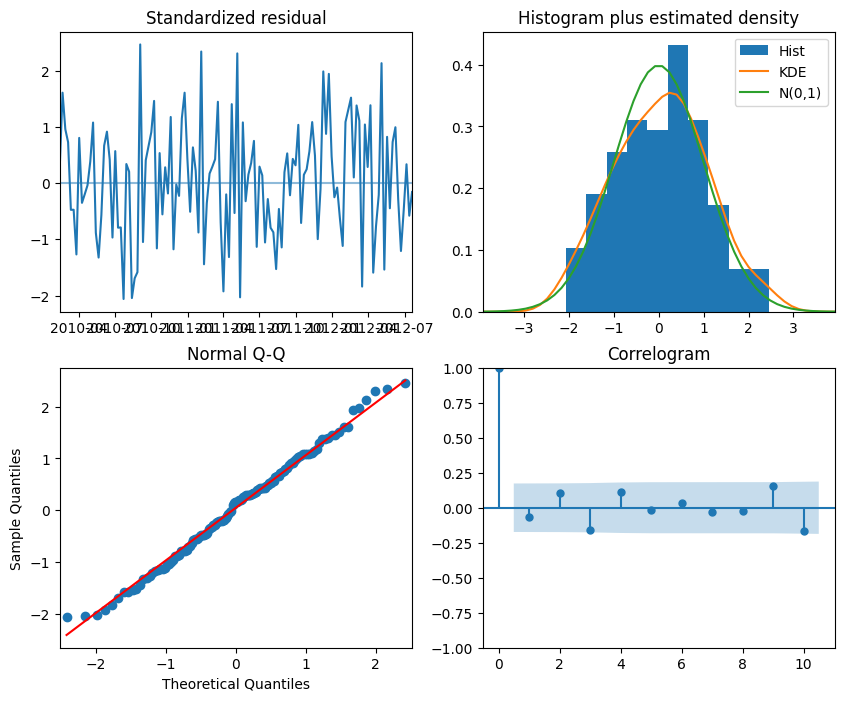

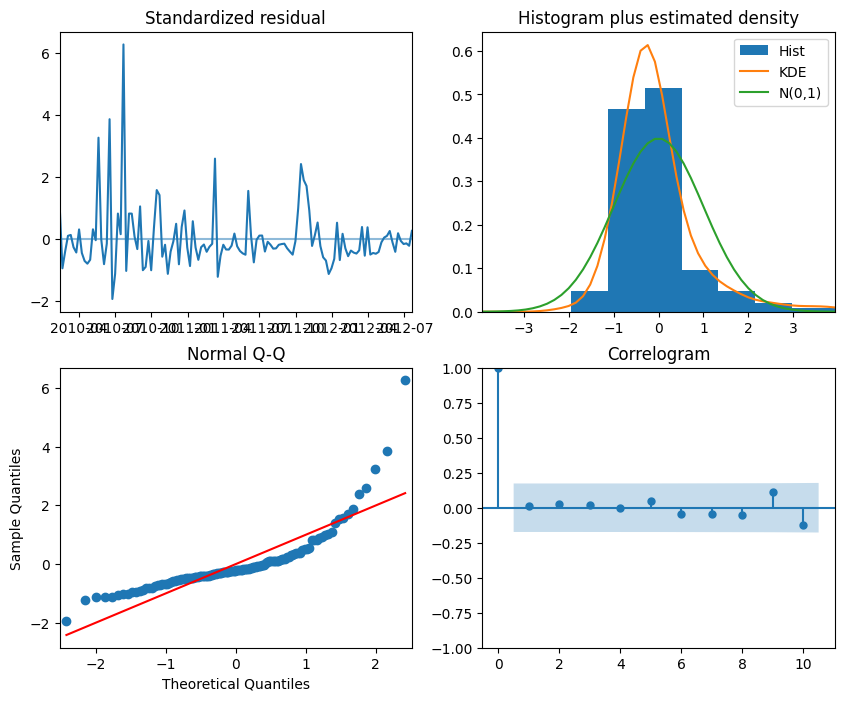

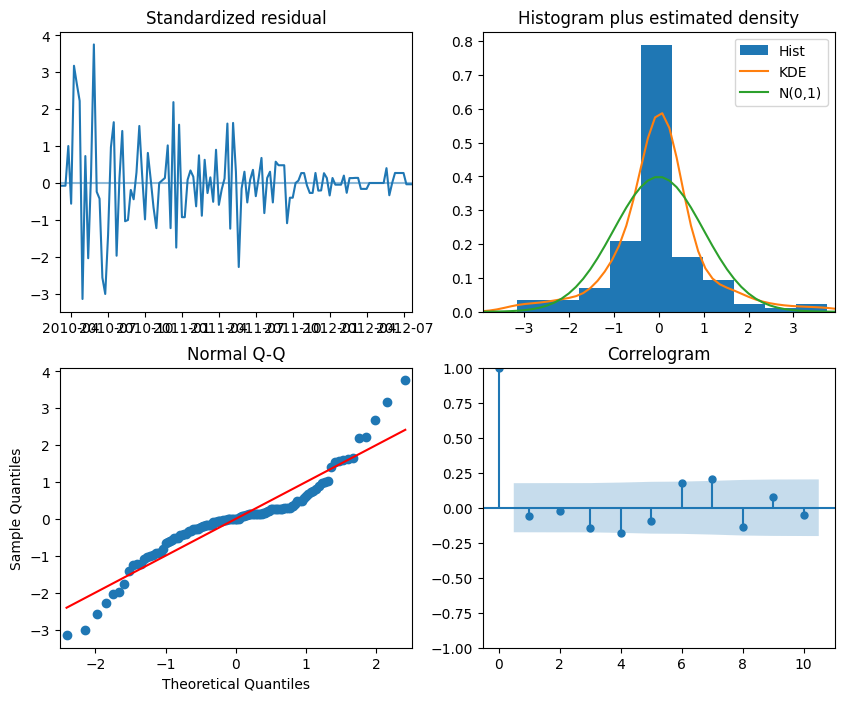

   store  dept  ljungbox_p_lag10  ljungbox_p_lag20  residuals_look_white_noise
0     14    92          0.363264          0.712963                        True
1      2    92          0.413995          0.832666                        True
2     20    92          0.025043          0.041175                       False
3     13    92          0.567868          0.945330                        True
4      4    92          0.360556          0.619825                        True
5     28    24          0.227480          0.008971                       False
6     45    22          0.599801          0.757918                        True
7      3     8          0.959905          0.993221                        True
8     17    45          0.873103          0.960686                        True
9     36    25          0.010407          0.020706                       False


In [11]:
run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_Diagnostics", job_type="diagnostics")

diag_results = []
for s, model in trained_models.items():
    resid = model.resid()
    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    diag_results.append({
        "store": s[0], "dept": s[1],
        "ljungbox_p_lag10": lb['lb_pvalue'].iloc[0],
        "ljungbox_p_lag20": lb['lb_pvalue'].iloc[1],
        "residuals_look_white_noise": bool(lb['lb_pvalue'].iloc[0] > 0.05 and lb['lb_pvalue'].iloc[1] > 0.05),
    })

    fig = model.plot_diagnostics(figsize=(10, 8))
    wandb.log({f"diagnostics_store{s[0]}_dept{s[1]}": wandb.Image(fig)})
    plt.show() # Added to view diagnostic plots inline
    plt.close()

diag_df = pd.DataFrame(diag_results)
print(diag_df)
wandb.log({"diagnostics_table": wandb.Table(dataframe=diag_df)})
wandb.finish()

## Section 12 — Evaluation Summary (`ARIMA_Evaluation`)

{'mean_val_wmae': np.float64(5951.471158843217), 'mean_naive_wmae': np.float64(8145.515706349205), 'pct_series_beating_naive': np.float64(60.0), 'n_series_evaluated': 10}


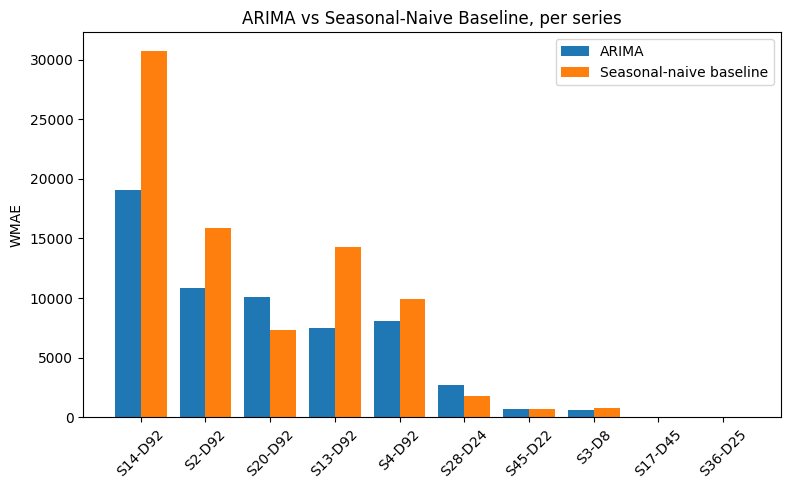

mean_naive_wmae,▁
mean_val_wmae,▁
n_series_evaluated,▁
pct_series_beating_naive,▁
mean_naive_wmae,8145.51571
mean_val_wmae,5951.47116
n_series_evaluated,10
pct_series_beating_naive,60


ARIMA_Evaluation run finished


In [12]:
run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_Evaluation", job_type="evaluation")

summary = {
    "mean_val_wmae": training_results_df['val_wmae'].mean(),
    "mean_naive_wmae": training_results_df['naive_wmae'].mean(),
    "pct_series_beating_naive": training_results_df['beats_naive'].mean() * 100,
    "n_series_evaluated": len(training_results_df),
}
print(summary)
wandb.log(summary)

plt.figure(figsize=(9, 5))
x = np.arange(len(training_results_df))
plt.bar(x - 0.2, training_results_df['val_wmae'], width=0.4, label='ARIMA')
plt.bar(x + 0.2, training_results_df['naive_wmae'], width=0.4, label='Seasonal-naive baseline')
plt.xticks(x, [f"S{r.store}-D{r.dept}" for r in training_results_df.itertuples()], rotation=45)
plt.ylabel("WMAE"); plt.legend()
plt.title("ARIMA vs Seasonal-Naive Baseline, per series")
wandb.log({"ARIMA_vs_Naive_Plot": wandb.Image(plt)})
plt.show() # Added to view evaluation plot inline
plt.close()

wandb.finish()
print("ARIMA_Evaluation run finished")

## Section 13 — Random-Sample Pooled Validation (`ARIMA_Pooled_Random_Sample_Validation`)

Complements the stratified 10-series diagnostic work above (Sections 4-12), which is intentionally
small and curated for theoretical rigor (stationarity testing, residual diagnostics, per-series
naive-baseline comparison). This section instead validates on a large **random** sample and reports
a single **pooled** WMAE across all predictions — matching how Kaggle's actual leaderboard metric
is computed (one weighted average over every row, not an average of per-series WMAEs).

The number below is expected to differ from `summary['mean_val_wmae']` for a real reason, not an
error: averaging per-series WMAEs equally weights a $10/week series the same as a $50k/week series,
while pooling naturally weights by how many predictions are actually involved — the same way
XGBoost's `val_wmae` is already computed. Report both numbers in the README, not just one; they
answer different questions.

In [13]:
run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_Pooled_Random_Sample_Validation", job_type="evaluation")

from pmdarima.arima import ARIMA as PmdARIMA

RANDOM_SAMPLE_SIZE = 180  # matches scale used elsewhere on the team for comparability
FIXED_ORDER = (1, 1, 1)   # fixed, not auto_arima -- stepwise search on 180 series would be slow
                          # and isn't the point here; this section checks aggregate robustness,
                          # not per-series optimal order (Sections 4-12 already cover that properly)

all_valid_series = list(series_lengths[series_lengths >= 100].index)
sampled_series = list(pd.Series(all_valid_series).sample(
    n=min(RANDOM_SAMPLE_SIZE, len(all_valid_series)), random_state=42))

pooled_actual, pooled_pred, pooled_weight = [], [], []
n_success, n_failed = 0, 0

for store, dept in sampled_series:
    try:
        data = prep_series(df, store, dept)
        exog = build_exog(data)

        train_mask = data.index <= cutoff_date
        val_mask   = data.index > cutoff_date
        train_s, val_s = data['Weekly_Sales'][train_mask], data['Weekly_Sales'][val_mask]
        train_exog, val_exog = standardize_exog_fold(exog[train_mask], exog[val_mask])

        if len(val_s) == 0 or len(train_s) < 52:
            n_failed += 1
            continue

        model = PmdARIMA(order=FIXED_ORDER, suppress_warnings=True)
        model.fit(train_s, exogenous=train_exog)
        preds = model.predict(n_periods=len(val_s), exogenous=val_exog)

        weights = np.where(val_exog['IsHoliday'].values == 1, 5, 1)
        pooled_actual.extend(val_s.values)
        pooled_pred.extend(np.asarray(preds))
        pooled_weight.extend(weights)
        n_success += 1

    except Exception:
        n_failed += 1
        continue

pooled_actual = np.array(pooled_actual)
pooled_pred   = np.array(pooled_pred)
pooled_weight = np.array(pooled_weight)
pooled_wmae = weighted_mae(pooled_actual, pooled_pred, pooled_weight)

print(f"Random sample: {len(sampled_series)} series attempted, {n_success} succeeded, "
      f"{n_failed} failed ({n_success/len(sampled_series)*100:.1f}% success rate)")
print(f"Total pooled predictions: {len(pooled_actual)}")
print(f"Pooled WMAE (Kaggle-consistent): {pooled_wmae:.2f}")
print(f"For comparison, mean-of-per-series WMAE from the stratified sample: {summary['mean_val_wmae']:.2f}")

wandb.log({
    "random_sample_size": len(sampled_series),
    "random_sample_success": n_success,
    "random_sample_failed": n_failed,
    "random_sample_success_rate": n_success / len(sampled_series) * 100,
    "pooled_wmae": pooled_wmae,
    "total_pooled_predictions": len(pooled_actual),
})

wandb.finish()
print("ARIMA_Pooled_Random_Sample_Validation run finished")

Random sample: 180 series attempted, 180 succeeded, 0 failed (100.0% success rate)
Total pooled predictions: 2520
Pooled WMAE (Kaggle-consistent): 3071.48
For comparison, mean-of-per-series WMAE from the stratified sample: 5951.47


pooled_wmae,▁
random_sample_failed,▁
random_sample_size,▁
random_sample_success,▁
random_sample_success_rate,▁
total_pooled_predictions,▁
pooled_wmae,3071.48385
random_sample_failed,0
random_sample_size,180
random_sample_success,180
random_sample_success_rate,100


ARIMA_Pooled_Random_Sample_Validation run finished


## Section 14 — Save Per-Series Pipeline (`ARIMA_Save_Models`)

Unlike XGBoost's single pooled model, ARIMA fits one model **per series**.
This wrapper only covers the sampled (Store, Dept) combinations trained above --
a full per-series pipeline for all ~3,000 combinations was explicitly out of scope
per the assignment's guidance to limit time spent on classical models. This
limitation is intentional and documented, not an oversight.

In [14]:
import pickle

run = wandb.init(project="walmart-sales-forecasting", group="ARIMA_Training",
                  name="ARIMA_Save_Models", job_type="pipeline-export")

class ARIMASeriesPipeline:
    """
    Holds one fitted ARIMA model per (Store, Dept) series, plus each series' own historical
    data needed to reproduce the exact exogenous feature matrix (Fourier phase, macro
    standardization stats) it was trained on. predict() takes RAW future rows (matching
    test.csv + features.csv merged, unprocessed) -- the caller doesn't need to know about
    Fourier terms or holiday-date tables at all.
    NOTE: only covers the stratified sample of series trained in this notebook.
    """
    def __init__(self, models_by_series, prepared_series, markdown_cols):
        self.models_by_series = models_by_series
        self.prepared_series = prepared_series
        self.markdown_cols = markdown_cols
        self.super_bowl    = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
        self.labor_day     = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
        self.thanksgiving  = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
        self.christmas     = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

    def _build_exog(self, store, dept, raw_future_df):
        ref_data = self.prepared_series[(store, dept)]
        idx = pd.to_datetime(raw_future_df['Date'])
        t = np.arange(len(ref_data), len(ref_data) + len(idx))

        exog = pd.DataFrame(index=idx)
        for k in range(1, 3):
            exog[f'sin_{k}'] = np.sin(2 * np.pi * k * t / 52.18)
            exog[f'cos_{k}'] = np.cos(2 * np.pi * k * t / 52.18)
        exog['IsHoliday']       = raw_future_df['IsHoliday'].astype(int).values
        exog['Is_SuperBowl']    = idx.isin(self.super_bowl).astype(int)
        exog['Is_LaborDay']     = idx.isin(self.labor_day).astype(int)
        exog['Is_Thanksgiving'] = idx.isin(self.thanksgiving).astype(int)
        exog['Is_Christmas']    = idx.isin(self.christmas).astype(int)
        exog['CPI']             = raw_future_df['CPI'].values
        exog['Unemployment']    = raw_future_df['Unemployment'].values
        exog['Fuel_Price']      = raw_future_df['Fuel_Price'].values
        exog['Total_Markdown']  = raw_future_df[self.markdown_cols].fillna(0).sum(axis=1).values
        exog['Has_Markdown']    = (exog['Total_Markdown'] > 0).astype(int)

        for col in ['CPI', 'Unemployment', 'Fuel_Price', 'Total_Markdown']:
            ref_col = ref_data[col] if col != 'Total_Markdown' else ref_data[self.markdown_cols].fillna(0).sum(axis=1)
            mu, sigma = ref_col.mean(), ref_col.std()
            exog[col] = (exog[col] - mu) / (sigma if sigma > 0 else 1)
        return exog

    def predict(self, store, dept, raw_future_df):
        key = (store, dept)
        if key not in self.models_by_series:
            raise ValueError(
                f"No trained ARIMA model for Store {store}, Dept {dept} -- "
                f"only the sampled series from Section 4 are covered."
            )
        exog = self._build_exog(store, dept, raw_future_df)
        return self.models_by_series[key].predict(n_periods=len(raw_future_df), exogenous=exog)

arima_pipeline = ARIMASeriesPipeline(trained_models, prepared_series, markdown_cols)

with open("/content/arima_pipeline.pkl", "wb") as f:
    pickle.dump(arima_pipeline, f)

artifact = wandb.Artifact(
    name="arima_series_pipeline", type="model",
    description=f"Per-series ARIMA models for {len(trained_models)} sampled Store-Dept series. "
                f"mean_val_wmae={summary['mean_val_wmae']:.2f} (10-series stratified average), "
                f"pooled_wmae={pooled_wmae:.2f} (180-series random sample, Kaggle-consistent)"
)
artifact.add_file("/content/arima_pipeline.pkl")
wandb.run.log_artifact(artifact)
wandb.finish()
print("ARIMA pipeline saved")

ARIMA pipeline saved
